# Target Classes

| Label | Class       |
| ----- | ----------- |
| 0     | T-shirt/Top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal      |
| 6     | Shirt       |
| 7     | Sneaker     |
| 8     | Bag         |
| 9     | Ankle Boot  |

# **Step 1: Import Required Libraries**
**Purpose**

Import all required libraries for data loading, visualization, ANN model building, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

# **Step 2: Load Fashion MNIST Dataset**
**Purpose**

Load built-in Fashion MNIST dataset.

In [9]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Image Shape :", X_train.shape)
print("Testing Image Shape :", X_test.shape)
print("Training Label Shape :", y_train.shape)
print("Testing Label Shape :", y_test.shape)

Training Image Shape : (60000, 28, 28)
Testing Image Shape : (10000, 28, 28)
Training Label Shape : (60000,)
Testing Label Shape : (10000,)


# **Step 3: Display Sample Images**
**Purpose**

Understand dataset visually.

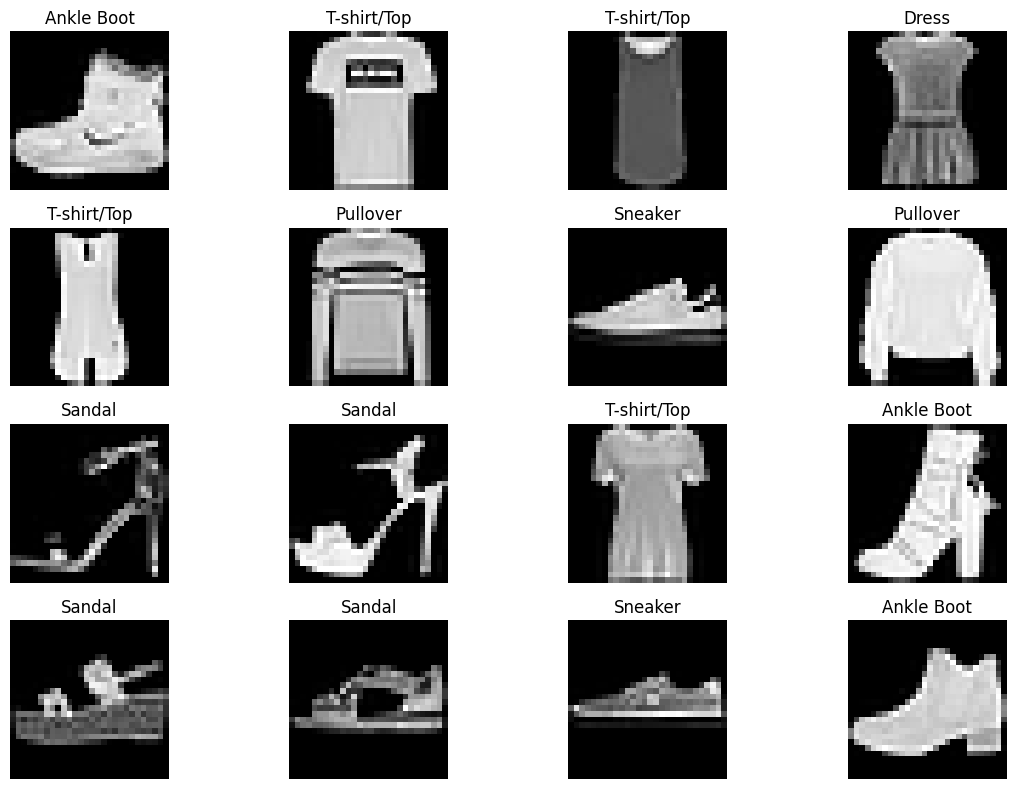

In [17]:
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize= (12,8))

for i in range(16):
  plt.subplot(4, 4, i+1)
  plt.imshow(X_train[i], cmap = 'gray')
  plt.title(class_names[y_train[i]])
  plt.axis('off')

plt.tight_layout()
plt.show()

# **Step 4: Visualize Class Distribution**
**Purpose**

Check balance of classes.

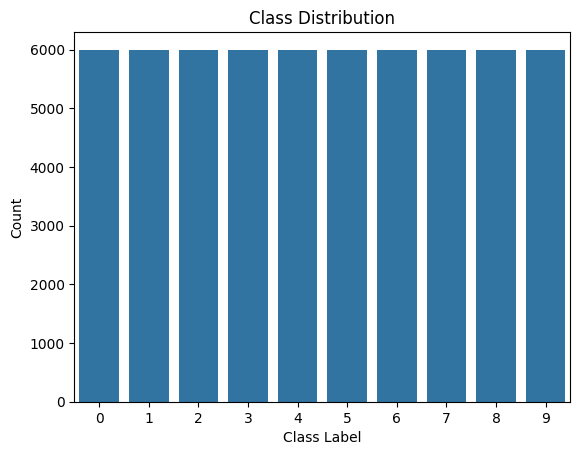

In [18]:
sns.countplot(x = y_train)
plt.title("Class Distribution")

plt.xlabel("Class Label")
plt.ylabel("Count")

plt.show()

# **Step 5: Normalize Pixel Values**
**Purpose**

Pixel values range from 0–255.

ANN works better when values are between 0 and 1.

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# **Step 6: Flatten Images**
**Purpose**

ANN accepts 1D input.

In [ ]:
# 28 * 28 = 784 Features

In [21]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


# **Step 7: One-Hot Encode Target Variable**
**Purpose**

Convert labels into categorical format.

In [ ]:
# 2 → [0 0 1 0 0 0 0 0 0 0]

In [22]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print(y_train_cat.shape)

(60000, 10)


# **Step 8: Build ANN Model**
**Purpose**

Create Neural Network Architecture.

In [23]:
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(512, activation= 'relu', input_shape = (784,)))

model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(256, activation = 'relu'))

model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(128, activation = 'relu'))

# Output Layer
model.add(Dense(10, activation= 'softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Step 9: Model Summary**
**Purpose**

Check architecture.

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

# **Step 10: Compile Model**
**Purpose**

| Parameter                       | Work                            |
| ------------------------------- | ------------------------------- |
| optimizer='adam'                | Weight optimization             |
| loss='categorical_crossentropy' | Multi-class classification loss |
| metrics=['accuracy']            | Accuracy measurement            |


In [25]:
from sklearn import metrics
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']

)

# **Step 11: Train ANN Model**
**Purpose**

Learn patterns from images.

In [26]:
from sklearn.utils import validation
history = model.fit(
    X_train,
    y_train_cat,
    validation_split = 0.2,
    epochs = 20,
    batch_size = 128,
    verbose = 1
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6418 - loss: 4.2394 - val_accuracy: 0.7547 - val_loss: 0.7795
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7163 - loss: 0.8577 - val_accuracy: 0.7841 - val_loss: 0.6309
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7514 - loss: 0.7119 - val_accuracy: 0.8218 - val_loss: 0.4997
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7775 - loss: 0.6219 - val_accuracy: 0.8282 - val_loss: 0.4804
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7910 - loss: 0.5805 - val_accuracy: 0.8345 - val_loss: 0.4726
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8033 - loss: 0.5457 - val_accuracy: 0.8418 - val_loss: 0.4437
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8116 - loss: 0.5207 - val_accuracy: 0.8397 - val_loss: 0.4377
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8188 - loss: 0.5017 - val_accuracy: 0.

# **Step 12: Plot Training Accuracy**
**Purpose**

Observe learning performance.

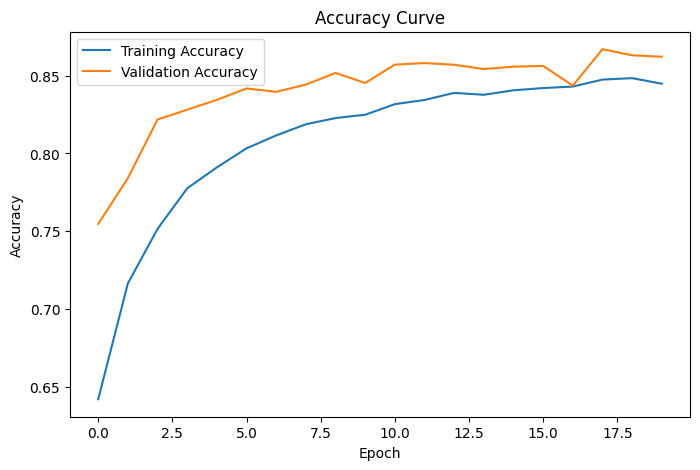

In [27]:
plt.figure(figsize = (8,5))

plt.plot(history.history['accuracy'],
         label = 'Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label = 'Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# **Step 13: Plot Loss Curve**
**Purpose**

Check error reduction.

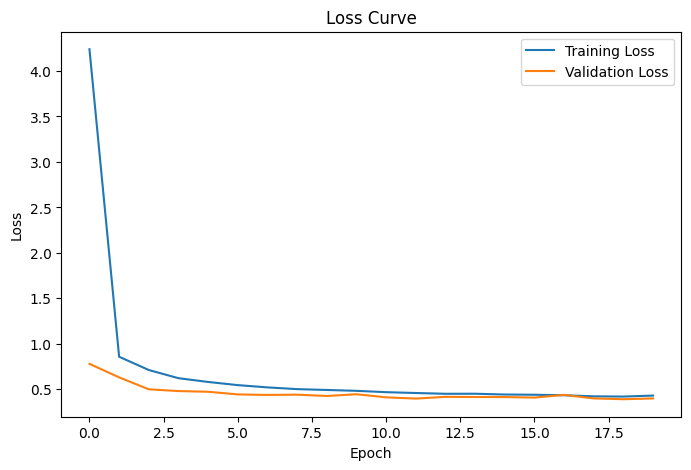

In [29]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label="Training Loss")

plt.plot(history.history['val_loss'],label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **Step 14: Evaluate Model**
**Purpose**

Check final performance on unseen data.

In [30]:
test_loss,test_accuracy = model.evaluate(
    X_test,
    y_test_cat
)

print("Test Loss : ", test_loss)
print("Test Accuracy :",test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8558 - loss: 0.4211
Test Loss :  0.42114776372909546
Test Accuracy : 0.8557999730110168


# **Step 15: Predict Test Data**
**Purpose**

Generate class predictions.

In [31]:
y_pred_prob = model.predict(X_test)

y_pred =np.argmax(y_pred_prob,axis=1)

print(y_pred[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[9 2 1 1 6 1 4 6 5 7]


# **Step 16: Classification Report**
**Purpose**

Detailed metrics.

In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1000
           1       0.99      0.95      0.97      1000
           2       0.75      0.71      0.73      1000
           3       0.85      0.89      0.87      1000
           4       0.77      0.71      0.74      1000
           5       0.95      0.97      0.96      1000
           6       0.59      0.64      0.61      1000
           7       0.94      0.94      0.94      1000
           8       0.96      0.97      0.96      1000
           9       0.96      0.95      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



# **Step 17: Confusion Matrix**
**Purpose**

Check class-wise performance.

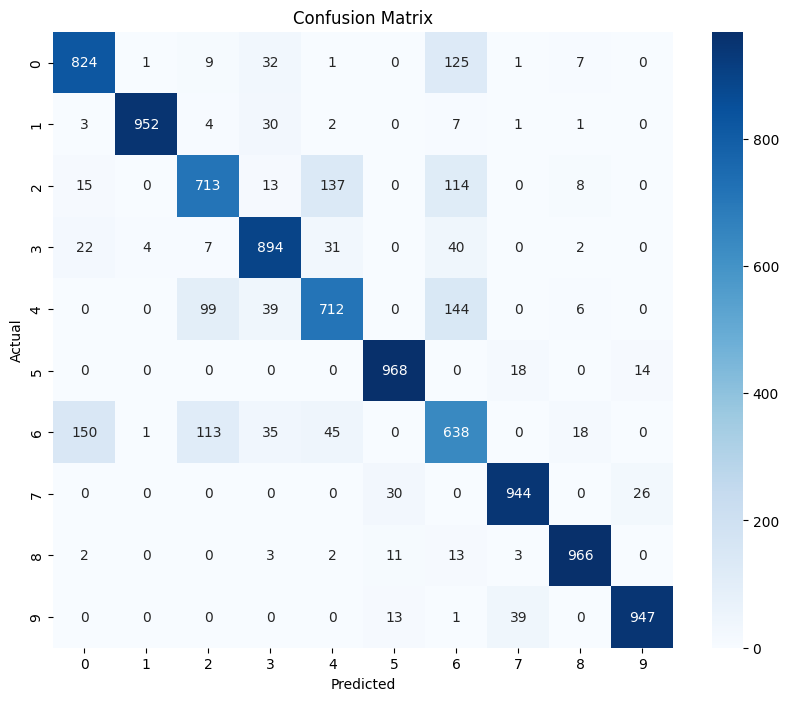

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# **Step 18: Display Actual vs Predicted Images**
**Purpose**

Visual verification

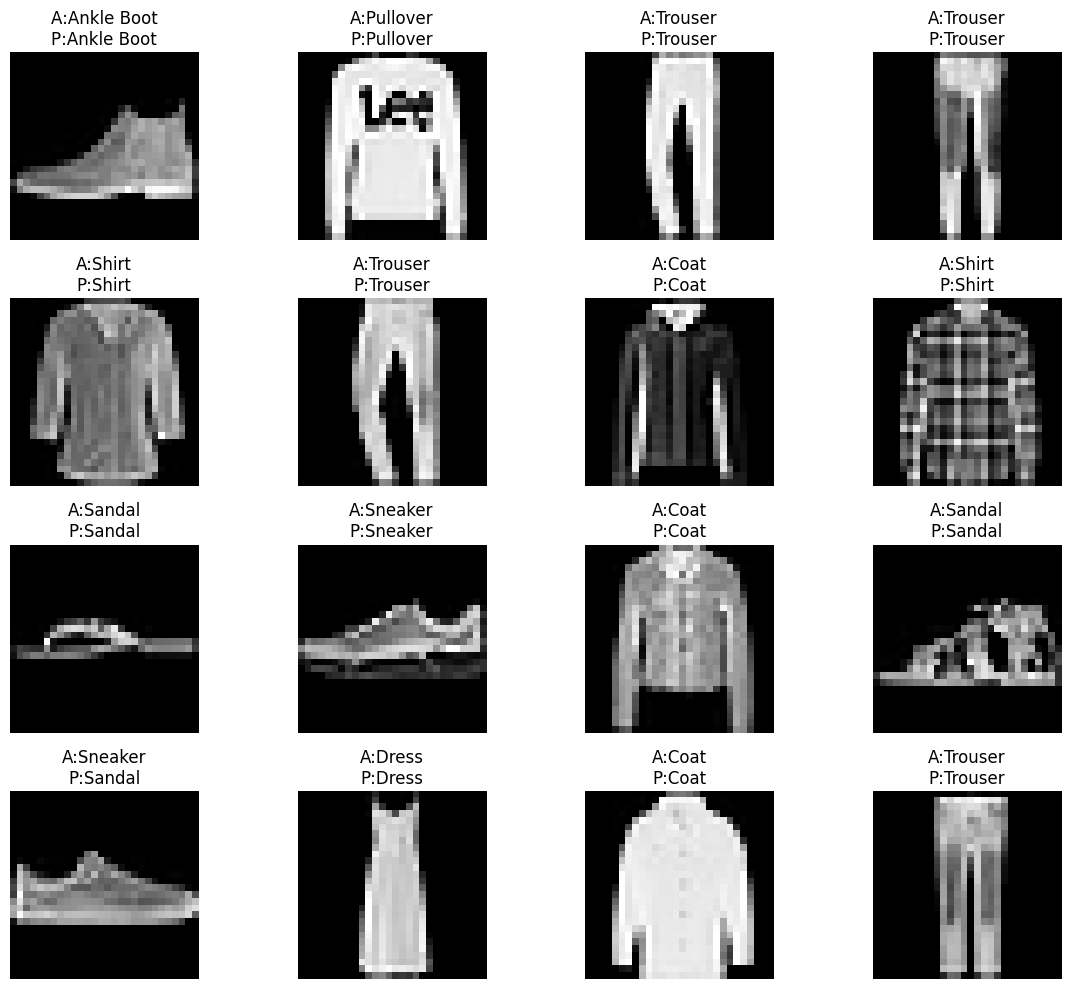

In [34]:
plt.figure(figsize=(12,10))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(X_test[i].reshape(28,28),
               cmap='gray')

    plt.title(
        f"A:{class_names[y_test[i]]}\nP:{class_names[y_pred[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# **Step 19: Predict New Single Image**
**Purpose**

Use ANN on a custom image.

In [35]:
index = 100

sample = X_test[index]

prediction = model.predict(
    sample.reshape(1,784)
)

predicted_class = np.argmax(prediction)

print("Predicted Class :",
      class_names[predicted_class])

print("Actual Class :",
      class_names[y_test[index]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
Predicted Class : Dress
Actual Class : Dress
